# Tutorial 20b: Multi-resolution Coherent Scale separation (mrCOSTS) using real data

This tutorial focuses on the real-world application the mrCOSTS object for multi-resolution coherent scale separation. In the toy-data example, the data include perfect oscillators as well as data engineered to be separable. Real world data is not so amiable. We provide this example with real data to illustrate how to use the mrCOSTS method on noisy, messy data. 

The real data also allows us to introduce the reason why mrCOSTS/COSTS operate with a different data model than the rest of PyDMD. Namely, mrCOSTS has _decomposition levels_ and _frequency bands_. The frequency bands are then further subdivided into the concepts of a _local_ and _global_ frequency bands. 

Each decomposition level provides a decomposition of the data by fitting BOP-DMD to a sliding window with a given length. For each decomposition level some number of _local_ frequency bands are found (using the `COSTS` module). The discrete frequency bands are found using a k-means clustering algorithm, introducing a hyperparameter of `n_components`, which can be specified for each level or found through a hyperparameter search. In either case, a frequency band separation results in separating the coherent spatiotemporal features for each decomposition level. 

mrCOSTS operates the opposite of other decompositions, fitting the fastest frequency bands and moving to the slowest. After separating the local frequency bands all but the slowest frequency band are removed from the data. The slowest frequency band is then given to the  next largest decomposition level (with a larger window) to fit.

After all decompositions have been completed, it is typical for information in a given frequency band to leak between decomposition levels. For this reason, _global_ frequency bands are found (using the `mrCOSTS` module). These global frequency bands are then used to describe the discrete, coherent spatiotemporal features from the data.

In [1]:
# netcdf/numpy/xray/stats
import numpy as np
import xarray as xr
import pandas as pd
import copy
import scipy

# OS interaction
import os
import sys
import glob

# import plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# PyDMD
from pydmd.costs import COSTS
from pydmd.mrcosts import mrCOSTS

import warnings

We ignore warnings because of the convergence warnings and the condition number warnings in BOP-DMD, which can number in the 100s to 1000s.

In [2]:
warnings.filterwarnings("ignore")

## Format plots

In [3]:
%matplotlib inline
# Higher resolution figures within the notebook
%config InlineBackend.figure_format = 'retina'

# Data

These data come from the Large-eddy Observatory, Voitsumra Experiment 2019 (LOVE19)$^{1}$. They are distributed temperature observations at 1 s and 0.127 m resolution along a 12 m tower in a valley bottom. These data are great for demonstrating the mrCOSTS because:

- They include a wide range of process scales that are not separable by other methods. Separating these scales is considered one of the biggest open questions boundary layer meteorology.
- There is substantial sensor noise. For the purposes of the tutorial we remove much of this noise using a rolling mean. mrCOSTS would determine the sensor noise and the small-scale turbulent processes as non-coherent. Consequently, mrCOSTS would drop them. However, the amplitudes of these scales are small but computationally expensive. The purpose of the rolling mean is to enable a quicker fitting process since we can skip right to the scale of the coherent processes.
- The data are 1D, which is simpler to visualize.


**Data Reference**

[1] https://zenodo.org/records/4312976

In [4]:
ds_data = xr.open_dataarray("../data/mrcosts-real-data-example.nc")

# The features being fit are much coarser than the instrument's resolution so
# we downsample the data.
ds_data = (
    ds_data.rolling(time=45, center=True).mean().dropna(dim="time", how="all")
)
# We only fit some of the data to speed up computation.
ds_data = ds_data.sel(time=slice(None, "2019-07-22 22:30"))
ts = ds_data.time
ts = ts - ts.isel(time=0)
ts = (ts / 1e9).values.astype(float)
dt = 1

data = ds_data.values

Text(0.5, 1.0, 'Input data for mrCOSTS')

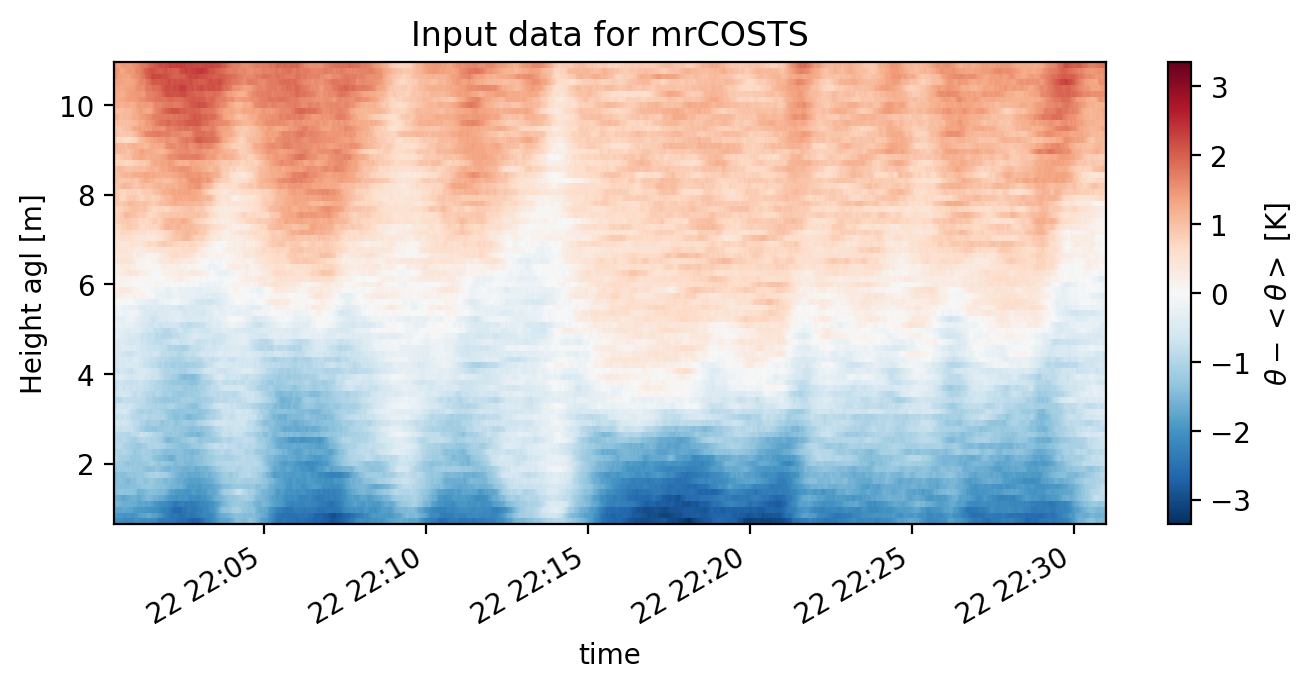

In [5]:
ds_data.plot(figsize=(8, 3))
plt.gca().set_title("Input data for mrCOSTS")

# Scale separation with the mrCOSTS object

Here we have a number of important keyword arguments and hyperparameters.

## Keywords:

- `window_length_array`: One of the fundamental properties of decompositions is the window length of the data that is decomposed. Unlike most other decompositions we must manually set these window sizes. In this case dyadic scaling works just fine so we specify the `window_length_array` keyword as the window lengths (in units of time steps) for each decomposition level. **Critical to note**: mrCOSTS operates in the opposite direction of most decompositions, starting from the smallest scales and moving the largest scales.
- `step_size_array`: For each decomposition we slide the window across the data in the time dimension. While we can do this for each time step, this is often unnecessarily computationally expensive. Instead, we "step" the window by a fixed number of time steps. The `step_size_array` specifies how to slide each window across the data. Here we chose a fixed slide of about 7%. Dylewsky et al., (2019) suggested 4%. Generally the slide width should be a small fraction of the window width.
- `svd_rank_array`: Specifies the svd_rank to use when fitting the BOP-DMD for each window. The `svd_rank` controls the number of frequency bands. Odd numbers force one of the fitted eigenvalues to have a large positive component. Even ranks tend towards fits with conjugate pairs. **Note**: one can force conjugate pair solutions using the BOP-DMD `eig_constraints` keyword argument.
- `global_svd_array`: Specifies if each level should use a global svd for the projection basis and initial eigenvalues using the entire dataset instead of individually for each window BOP-DMD fits (`True`) or not (`False`). Setting this value to True forces all of the BOP-DMD solutions towards eigenvalues representative for the entire data set and not just the specific window being fit. Generally using the global_svd speeds up the fitting process with the trade-off of not fitting dynamics which are not present throughout the entire dataset.
- `cluster_sweep`: Specifies if mrCOSTS should performa hyperparameter sweep when clustering the fitted eigenvalues from each window. When `True` it looks for the optimal number of eigenvalue clusters using the Silhouette score. If `False `the `n_components_array` keyword must be provided, specifying the number of frequency bands to use when clustering the fitted eigenvalues.
- `transform_method` dictates how the eigenvalue frequencies (the imaginary components) are transformed for the scale-separation step. See the below histograms for an illustration. Generally, for real data we find that `transform_method="absolute_value"` is the more reliable option.
- `eig_constraints` can be provided (see `bopdmd` module) using `pydmd_kwargs`. In testing, strict eigenvalue constraints do not perform well (e.g., `stable`  or `imag` constraints). We always recommend using the `conjugate_pairs` eigenvalue constraint as the definition of a DMD model becomes ambiguous otherwise.
- `relative_filter_length` specifies how strongly to weight the reconstructions towards the middle of each window. Large values = more weighting, small values = less weighting.
- `kern_method` specifies whether the fitted data should be rounded towards zero at the edges of time domain (`kern_method="kern"`) or not (`kern_method="flat"`). Kerning the data prior to fitting is not recommended as it can distort the fitted frequency time scales.

In [6]:
# Parameters
window_lengths = np.array([15, 30, 60]) * 10
step_sizes = np.array([1, 2, 3, 6]) * 10
sr = 10
svd_ranks = [sr] * len(window_lengths)
global_svd_array = [False] * len(window_lengths)
relative_filter_length = 4
kern_method = "flat"
real_eig_limit = 0.5
pydmd_kwargs = {
    "eig_constraints": {"conjugate_pairs", "limited"},
    "real_eig_limit": real_eig_limit,
}

# Due to the computational expense of mrCOSTS it often makes sense to
# save the fit results. These strings can be used to identify the particular
# fit combination in the saved file.
saved_fit_name = "mrcosts-tutorial-real-data"

The `fit` variable just specifies if the fitting should be performed and the new fit saved (`fit = True`) or if the saved model is used instead (`fit = False`).

In [7]:
fit = True

if fit:
    mrc = mrCOSTS(
        svd_rank_array=svd_ranks,
        window_length_array=window_lengths,
        step_size_array=step_sizes,
        global_svd_array=global_svd_array,
        cluster_sweep=True,
        transform_method="absolute",
        kern_method=kern_method,
        relative_filter_length=relative_filter_length,
        pydmd_kwargs=pydmd_kwargs,
    )

    mrc.fit(data, np.atleast_2d(ts))

_________________________________________________
Fitting window length = 150
0 of 170
50 of 170
100 of 170
150 of 170
Error in Global Reconstruction = 0.024
_________________________________________________
Fitting window length = 300
0 of 78
50 of 78
Error in Global Reconstruction = 0.011
_________________________________________________
Fitting window length = 600
0 of 43
Error in Global Reconstruction = 0.0018


## I/O

Due to the computation expense of the mrCOSTS fitting, it is desirable to execute this step only once, save the results, and only operate on the model offline. For this reason, we built mrCOSTS to be compatible with xarray, enabling storage as a self-describing dataset in netcdf format.

### To netcdf

In [8]:
if fit:
    mrc.to_netcdf(os.path.join("./fitted model/", saved_fit_name))

### Convert from netcdf

In [9]:
file_list = glob.glob(
    os.path.join("./fitted model/", "*" + saved_fit_name + "*.nc")
)
mrc = mrCOSTS()
mrc.from_netcdf(file_list)

# Evaluation plots

## Individual decomposition level comprehensive plots

These plots can be easily iterated through. But for the purpose of the tutorial, we present only a single decomposition level.

The plot types all  assume 1D data (as this is the shape required by PyDMD). We chose to not develop other visualization methods since the dimensionality of data can change dramatically between applications. However, if there is a consistent use case additional evaluation plots can (and should!) be added.

Plot types for each local decomposition:
1) Histogram of DMD frequencies ($\omega$). There are several options for how to express $Im(\omega)$: $|Im(\omega)|$, $Im(\omega)^2$, $log(|Im(\omega)|)$. A good choice of transformation will have the $Im(\omega)$ frequency bands well-separated from each other. **Note** this approach to clustering on $Im(\omega)$ is a change from Dylewsky et al., 2019, who clustered on $\omega^2$, whcih includes the real component dictating exponential growth and decay of the temporal modes.
2) Error in the global reconstruction expressed as a percent
3) Coherent scale separation with input data and each discrete frequency band.
4) Coherent scale separation with input data, low frequency component, and the high frequency component. The low frequency component is the input for the next decomposition scale.
5) Time series of the scale separation at a single point given by `space_index`.

In [10]:
# Choose a local decomposition level to examine
n_decomp = 1
mrd = mrc.costs_array[n_decomp]

# The data for each decomposition level is built here to avoid
# reconstructing the data for each plot. If this is not done the
# plots can still be rendered but will take slightly longer.
if n_decomp == 0:
    x_iter = data
else:
    x_iter, _ = mrc.costs_array[n_decomp - 1].scale_separation(
        scale_reconstruction_kwargs=mrc._costs_recon_kwargs
    )

The histogram of the fitted eigenvalues with the cluster centroids from the k-mean clustering indicated by vertical lines. In this case the cluster centroids are very well-separated and easily identified by the k-means clustering. The lowest frequency band (blue) is withheld for the next decomposition level.

Text(0.5, 0.98, 'Window length=300')

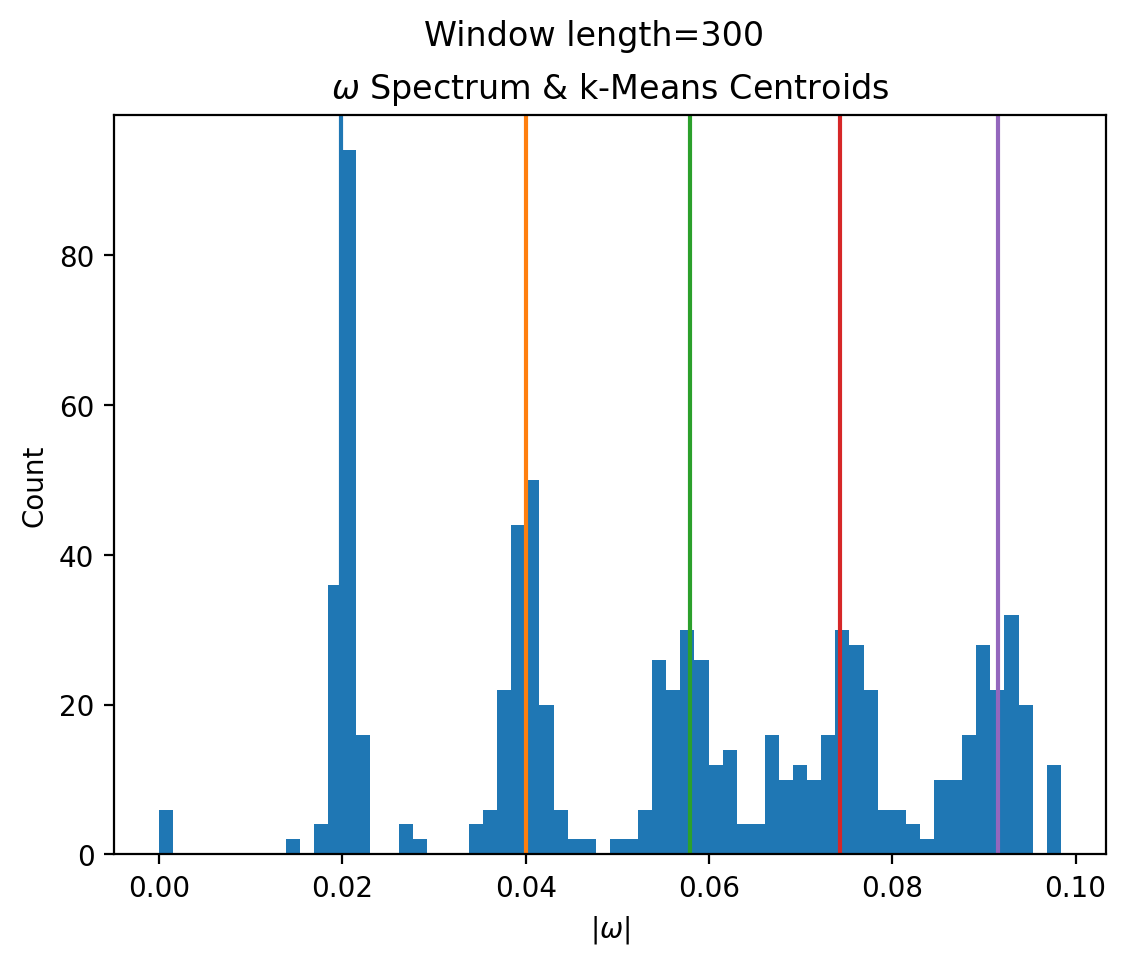

In [11]:
fig1, ax1 = mrd.plot_omega_histogram()
fig1.suptitle("Window length={}".format(mrd.window_length))

A good check is to look at the error in the global reconstruciton of the data. Specifically, we want to examine if there are specific time windows which were poorly fit. These often indicate a different set of mrCOSTS hyperparameters (e.g., `svd_rank`) may be necessary for this decomposition level.

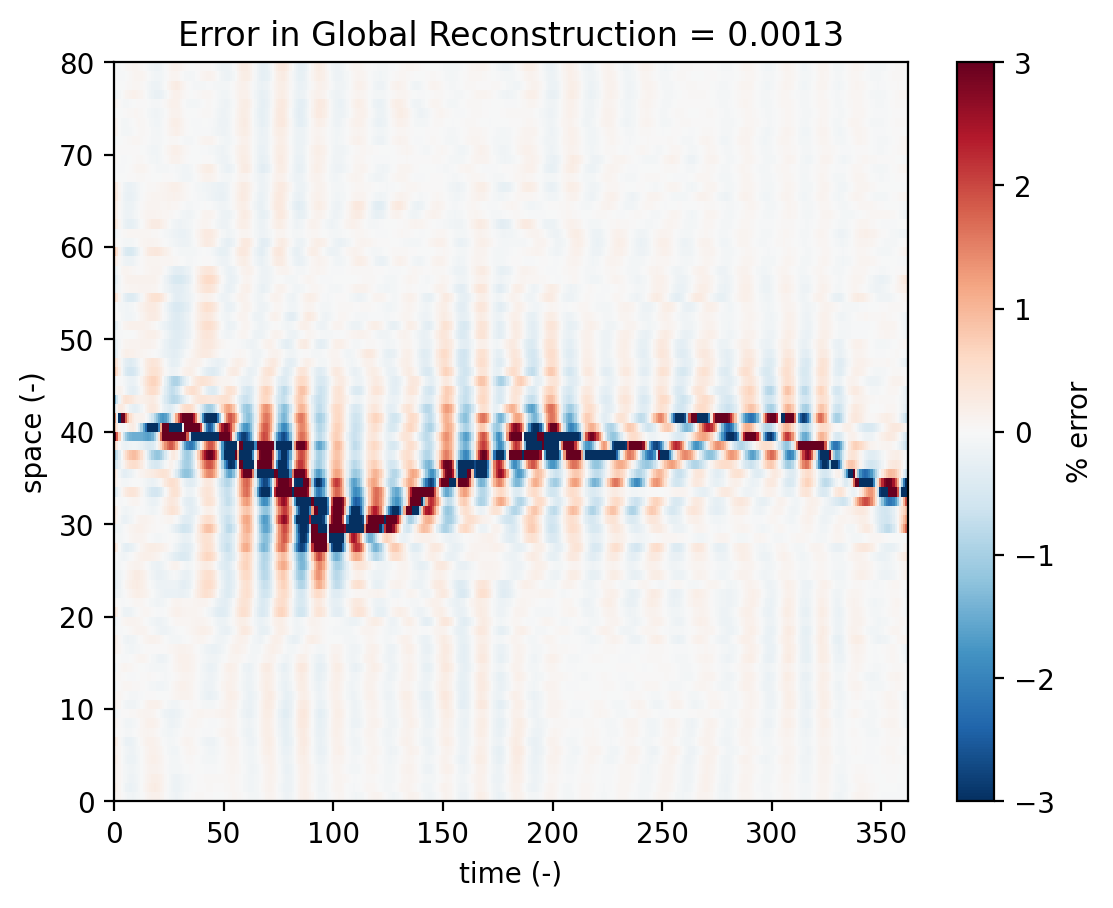

In [12]:
# Error in global reconstruction
mrc.plot_local_error(
    n_decomp, data=x_iter, scale_reconstruction_kwargs=mrc._costs_recon_kwargs
)

The coherent spatial patterns found for this local decomposition can be plotted. The first plot looks at the scale separation between the high frequency component localized in this decomposition level and the low-frequency component that was given to the next largest decomposition level. The second plot looks at the spatiotemporal patterns of each frequency band.

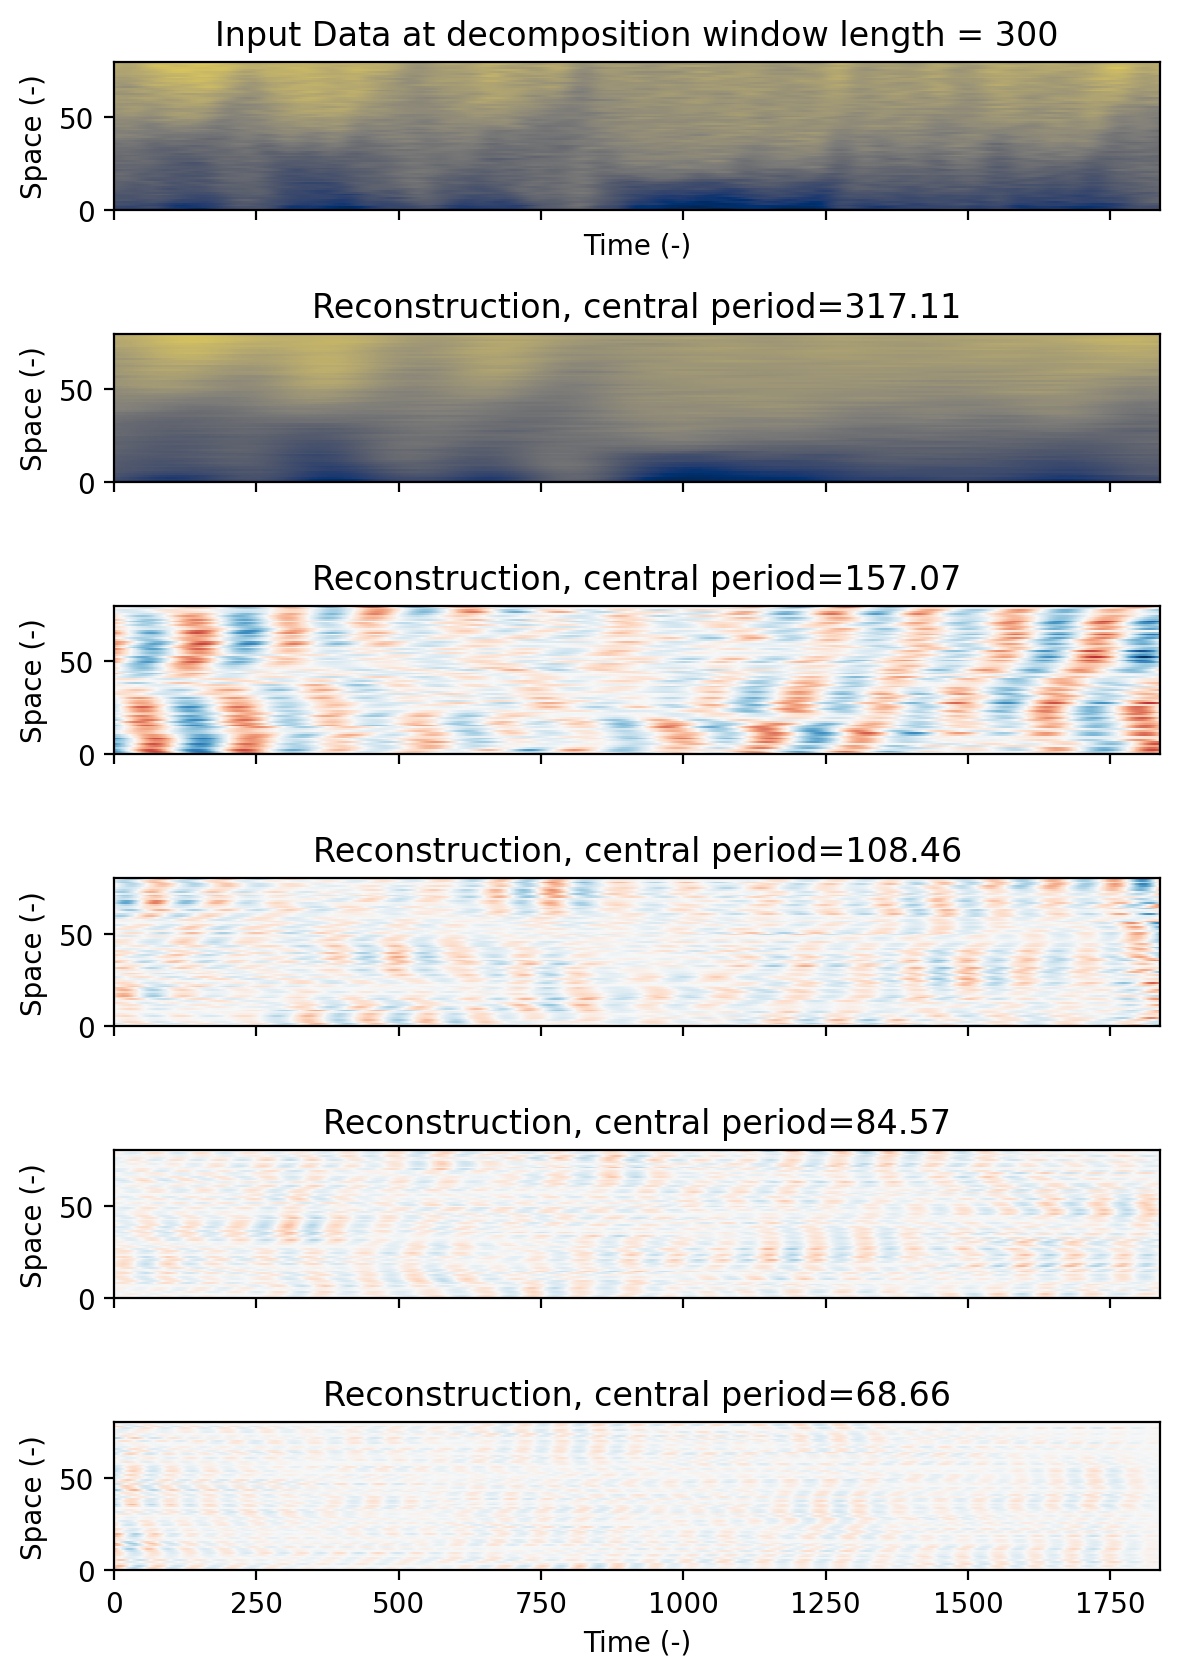

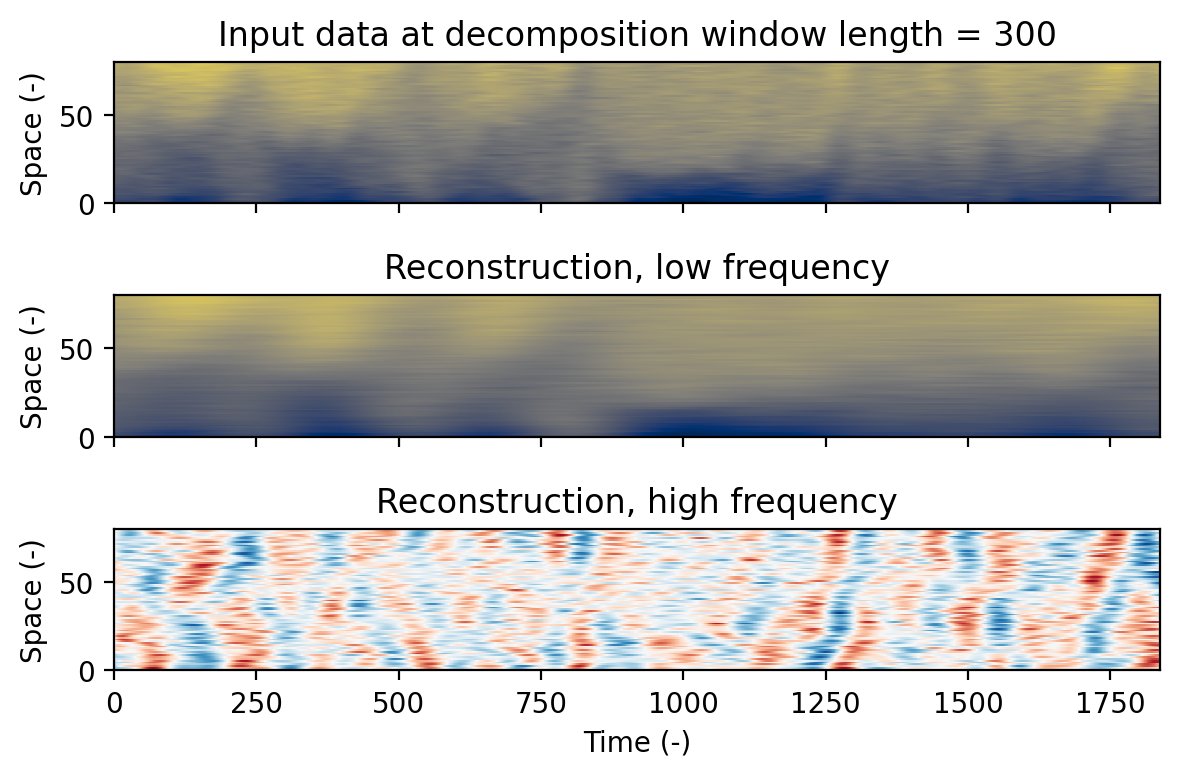

In [13]:
# Scale separation
_ = mrc.plot_local_reconstructions(
    n_decomp,
    data=x_iter,
    kwargs={"plot_period": True},
    scale_reconstruction_kwargs=mrc._costs_recon_kwargs,
)

# Alternatively you can use the local scale separation to visualize the individual frequency bands
# seen in the eigenvalue histogram.
_ = mrc.plot_local_scale_separation(
    n_decomp, data=x_iter, scale_reconstruction_kwargs=mrc._costs_recon_kwargs
)

Sometimes it is difficult to visualize the scale separation for spatially explicit data, especially since humans are sometimes bad at seeing small changes in relative color intensity. We can instead view how the decomposition performed for single point in space. 

**Important to note:** mrCOSTS is not analogous to normal signal analysis technqiues, it found the spatially coherent signals, not all time scales present in the time series.

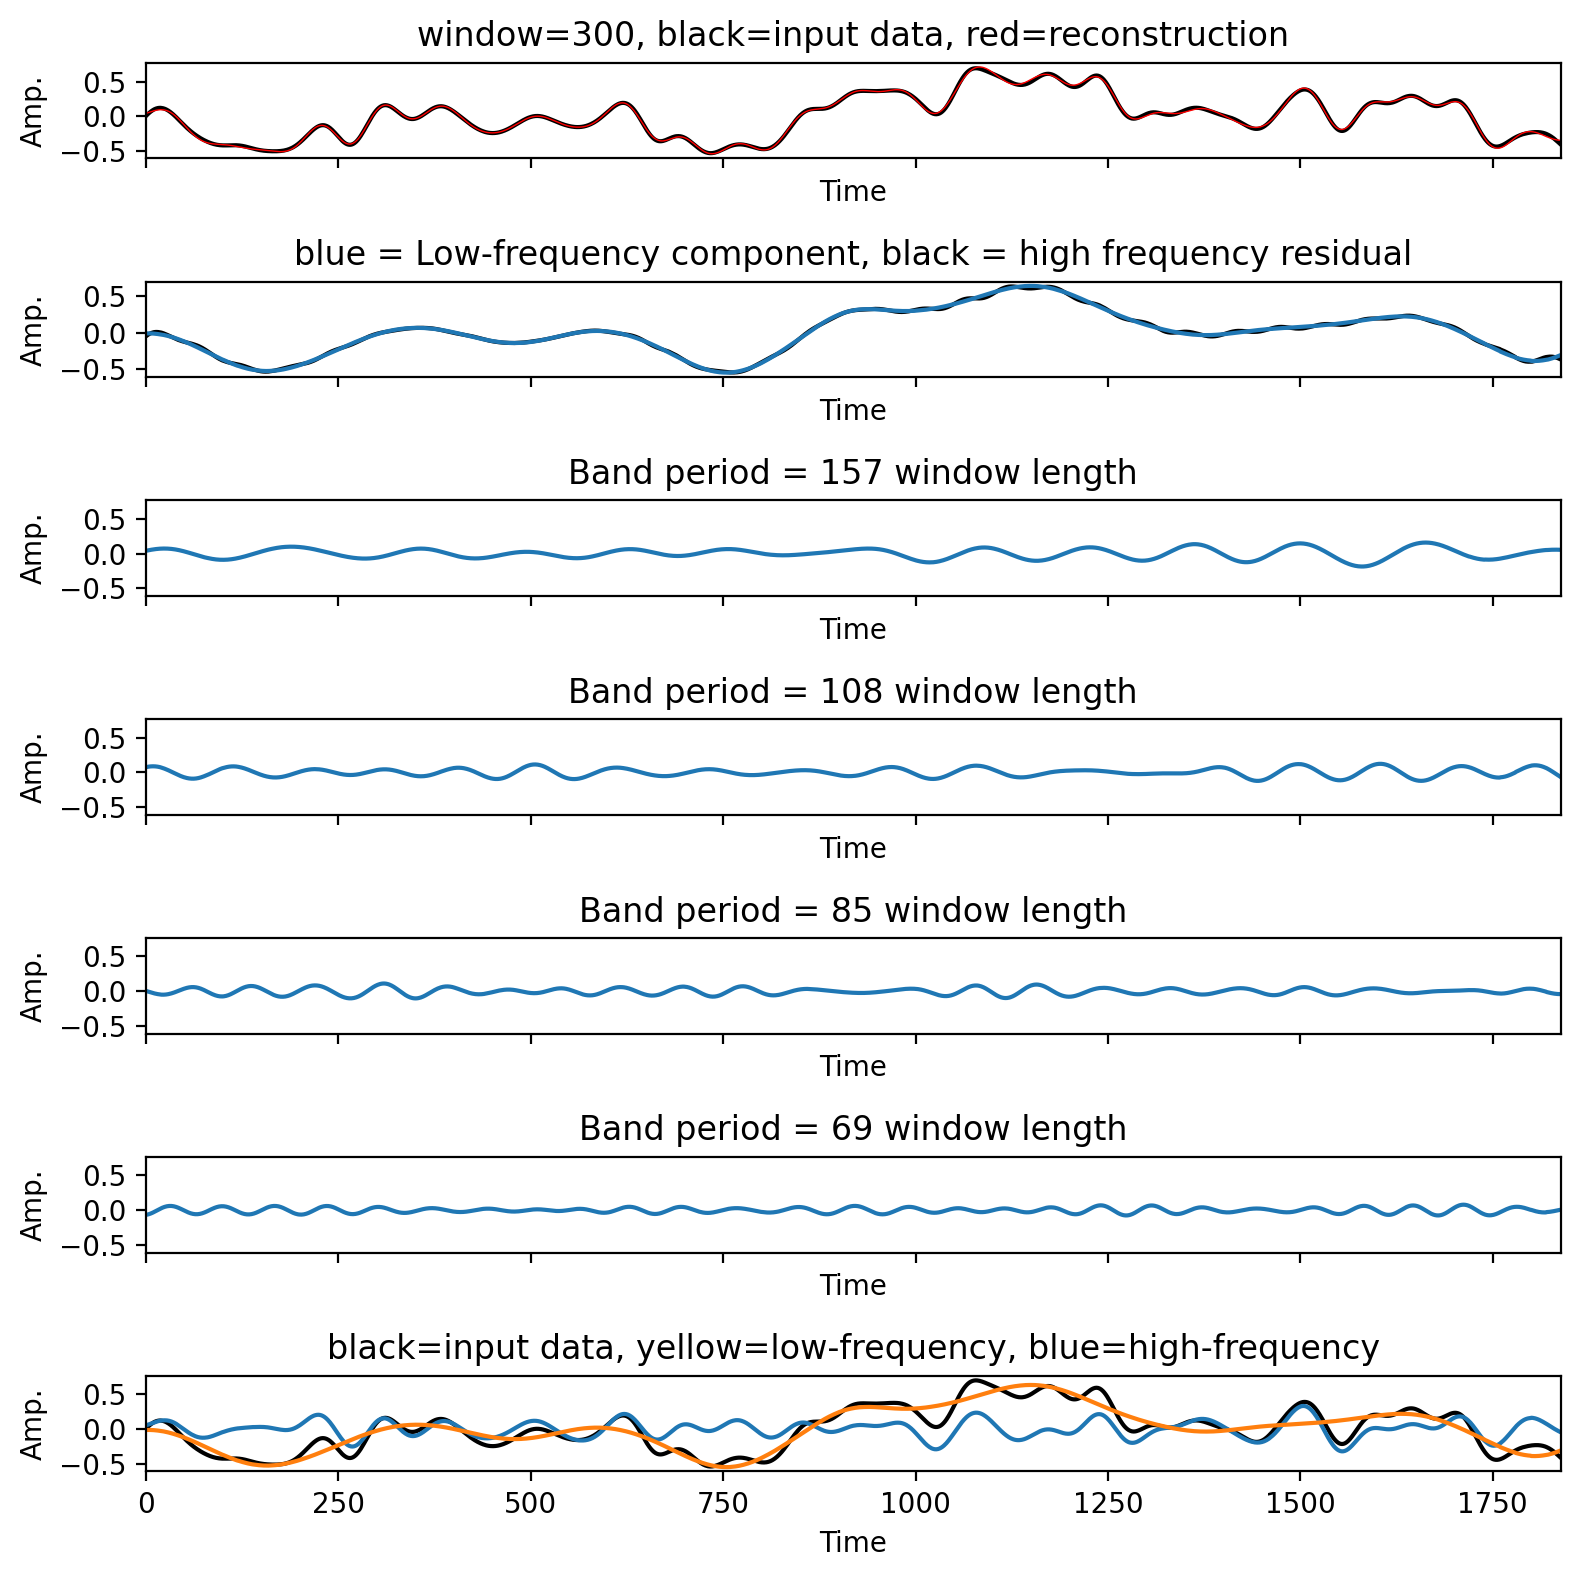

In [14]:
# Single points in space
space_index = 40
_, _ = mrc.plot_local_time_series(
    space_index,
    n_decomp,
    x_iter,
    scale_reconstruction_kwargs=mrc._costs_recon_kwargs,
)

## Information leaking between decomposition levels

To visualize the effect of the information leaking we can look at the relative amplitudes of the modes.

Text(0.5, 1.0, 'Normalized mode spatial amplitude for each decomp. level')

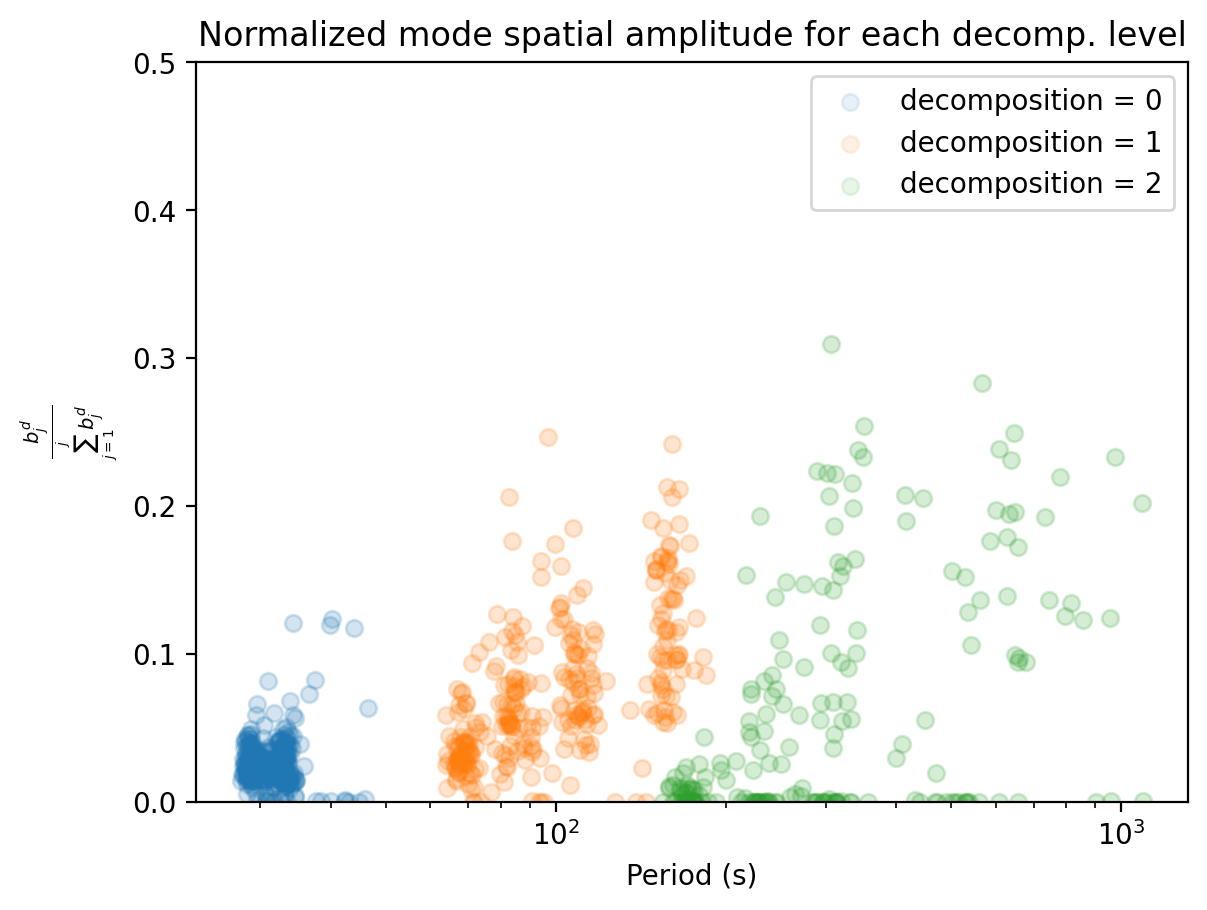

In [15]:
fig, ax = plt.subplots(1, 1)
for nm, m in enumerate(mrc.costs_array):
    # Extract out the amplitudes of the spatial modes
    b = m.amplitudes_array

    # Ratio of spatial amplitude for each mode relative to the amplitudes for all
    # high frequency modes (selected using the `omega_classes > 0` indexing)
    sum_b_ratio = (b.T / np.sum(b, axis=1)).T[m.omega_classes > 0].real
    mode_periods = m.periods()

    ax.scatter(
        x=mode_periods,
        y=sum_b_ratio,
        alpha=0.1,
        label="decomposition = {}".format(nm),
    )

ax.set_ylim(0, 0.5)
ax.legend()
ax.set_xscale("log")
ax.set_ylabel(r"$\frac{b^{d}_j}{\sum^{j}_{j=1}b^{d}_j}$")
ax.set_xlabel("Period (s)")
ax.set_title("Normalized mode spatial amplitude for each decomp. level")

Each color indicates a different decomposition level. Some interesting features emerge. First, the largest amplitude modes for these data are largely located at the largest time scales. Second, some decomposition levels seem to overlap in their time scales. Thrid, most decomposition levels yield discrete frequency bands while the lowest decomposition level (with the smallest time scales) is more of a "mush" of time scales. This is consistent witht the physical interpretation of these data.

**Information leaking:** Most decomposition levels have an overlap between the largest time scales from window $n$ and the smallest time scales in window $n+1$. Often the amplitude of the smallest time scales from decomposition level $n+1$ are relatively smaller than the amplitudes from decompositoin level $n$. But, this informaiton still leaks and a robust scale separation will need to account for this. We go over how to handle these cases below.

You normally do not need to do this step, but we are doing it here to give a view behind the scenes into what mrCOSTS is doing. Normally you could just skip directly to the evaluation.

## All decomposition levels

This next plot gives a sense of how mrCOSTS performs across all decomposition levels. For each level the high frequency component, which is removed, and the low-frequency component, which is passed to the next level, are shown. Since the low-frequency component includes the slow evolving background values it is plotted in a perceptually uniform color scale. The high frequency component is perturbations around zero so it is plotted in a diverging color scale. All levels are plotted using the same color map scaling.

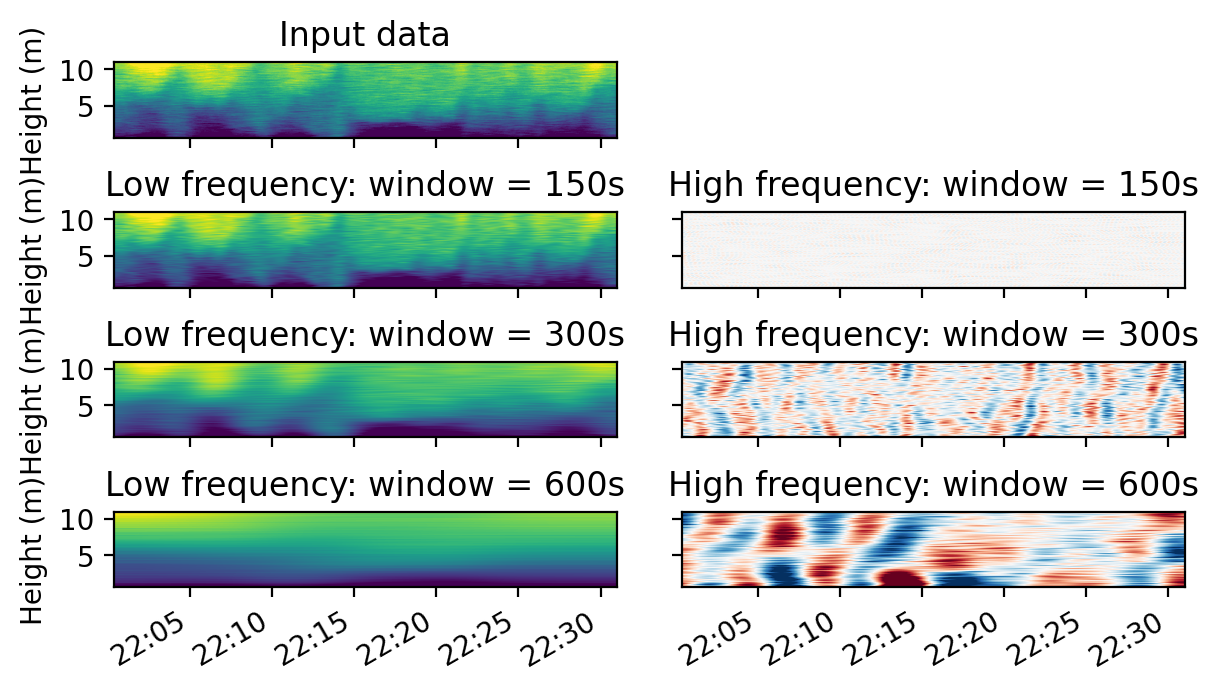

In [16]:
vscale = 0.5
fig, axes = plt.subplots(
    mrc.n_decompositions + 1,
    2,
    figsize=(6.25, mrc.n_decompositions * 1.25),
    sharex=True,
    sharey=True,
)

plot_kwargs = {
    "cmap": "RdBu_r",
    "vmin": -vscale,
    "vmax": vscale,
}

plot_kwargs_lf = {
    "cmap": "viridis",
    "vmin": -2,
    "vmax": 2,
}

ax = axes[0, 0]
ax.pcolormesh(ds_data.time.values, ds_data.z.values, data, **plot_kwargs_lf)
ax.set_title("Input data")
ax.set_ylabel("Height (m)")

axes[0, 1].axis("off")
for nm, m in enumerate(mrc.costs_array):
    xr_low_frequency, xr_high_frequency = m.scale_separation()

    ax = axes[nm + 1, 1]
    ax.pcolormesh(
        ds_data.time.values, ds_data.z.values, xr_high_frequency, **plot_kwargs
    )
    ax.set_title("High frequency: window = {}s".format(m._window_length * dt))

    ax = axes[nm + 1, 0]
    ax.pcolormesh(
        ds_data.time.values,
        ds_data.z.values,
        xr_low_frequency,
        **plot_kwargs_lf,
    )
    ax.set_title("Low frequency: window = {}s".format(m._window_length * dt))
    ax.set_ylabel("Height (m)")

axes[-1, 0].xaxis.set_major_formatter(DateFormatter("%H:%M"))

fig.tight_layout()
fig.autofmt_xdate()

The low frequency (left column) shows the data that the next decomposition level will fit. The high frequency components (right column) show the features that were removed at this decomposition level.

# Global clustering and frequency band separation

The leaking of information between decomposition levels forms a major obstacle since a frequency band found at any given level is missing information that likely leaked to the next level. Generally, the amplitudes are mostly confined to a single decomposition level (see above). But there is often enough leaking that we cannot discard frequency bands from other decomposition levels. The exact cause of this leaking is uncertain for now (bad fits? over fitting? not handling noise?).

To deal with the information leaking we perform a final "global" clustering and scale separation on the entire multi-resolution decomposition. This global scale separation should then be used in place of the "local" scale separation shown in the above evaluation plots.

## Interpolate to common time step

The biggest issue in the global scale separation is the different number of fitted windows for each decomposition level. To get around this issue we need to somehow normalize between the many windows in the first decomposition level (with the smallest windows) with the small number of windows in the last decomposition level (with the largest windows).

We chose to interpolate all decomposition levels to the time step of the smallest time step from the first decomposition level. 

In this multi-resolution interpolation step the low frequency cluster is removed and replaced by nans.

In [17]:
mrc.multi_res_interp()
df = mrc._da_omega.to_dataframe()

## Visualizing the leaking

## Cluster in a log scale

Text(0, 0.5, 'Weighted Count (-)')

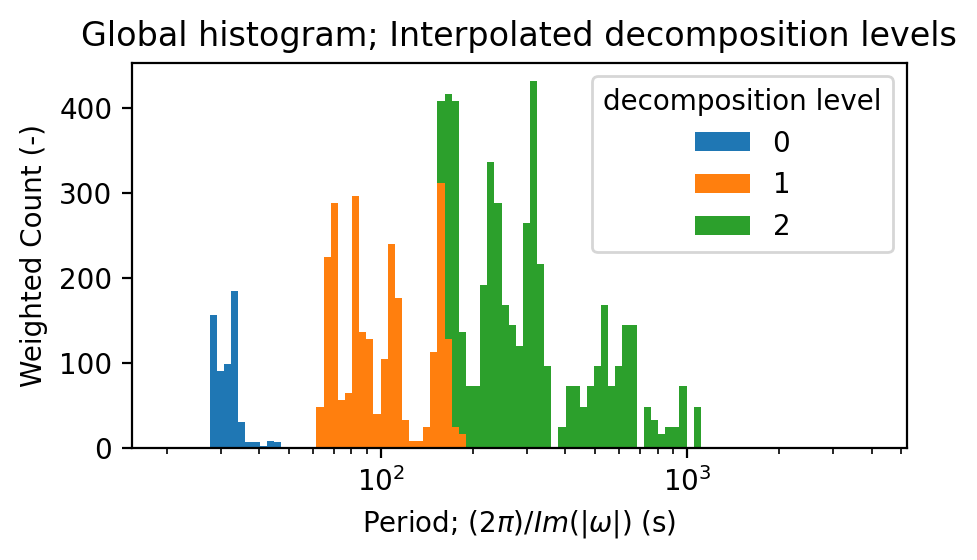

In [18]:
plt.figure(figsize=(5, 2.5))

da = mrc._da_omega
x = da.values
x = x.reshape(
    len(da.window_length), len(da.window_time_means) * len(da.svd_rank)
)
x_trans = (2 * np.pi) / np.abs(x.imag)

# Provide weights so that the smallest decomposition level and the largest
# are visually comparable (this also foreshadows the interpolation problem below).
weights = mrc.window_length_array / mrc.window_length_array[0]
weights = np.broadcast_to(np.atleast_2d(weights).T, (x_trans.shape))

plt.hist(
    x=x_trans.T,
    bins=np.logspace(start=np.log10(20), stop=np.log10(4000), num=100),
    histtype="barstacked",
    label=range(mrc.n_decompositions),
    weights=weights.T,
)
plt.xscale("log")
plt.legend(title="decomposition level")
plt.gca().set_title("Global histogram; Interpolated decomposition levels")
plt.gca().set_xlabel(r"Period; $(2 \pi) / Im(|\omega|)$ (s)")
plt.gca().set_ylabel("Weighted Count (-)")

We can see that processes were fit across multiple decomposition windows where any frequency has stacked colors, which show the decomposition level. 

## Global Clustering

To address the information leaking a global scale separation is performed (part 3 of the PNAS Figure 1).

As with the local clustering, the global clustering makes use of the MiniBatches k-means clustering from sklearn. The free parameter is again the number of components, `n_components`. We could probably make a reasonable guess for the optimal number of clusters to fit. But, a hyperparameter sweep function is provided when the optimal number is unclear or to enable objective selection.

Notes:
- The silhouette scoring is the slowest part of the hyperparameter sweep.
- The calinski-harabasz score is not useful due to (nearly) monotonically increasing with `n_components`. It can be used instead of the silhouette score but is not recommended.

fitting n_components = 8
fitting n_components = 9
fitting n_components = 10
fitting n_components = 11
fitting n_components = 12
fitting n_components = 13
fitting n_components = 14
fitting n_components = 15
fitting n_components = 16
fitting n_components = 17
Optimal silhouette score is = 10


Text(0, 0.5, 'Silhouette score (-)')

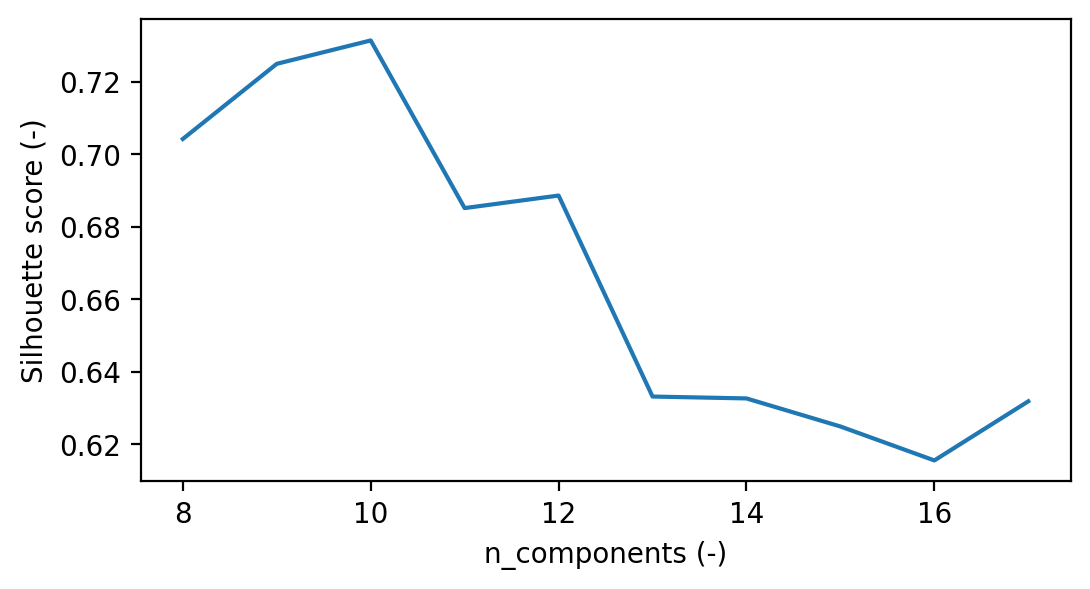

In [19]:
n_components_range = np.arange(8, 18)
scores, n_optimal = mrc.global_cluster_hyperparameter_sweep(
    n_components_range,
    transform_method="log10",
)

print("Optimal silhouette score is = {}".format(n_optimal))
plt.figure(figsize=(6, 3))
plt.plot(n_components_range, scores)
plt.gca().set_xlabel("n_components (-)")
plt.gca().set_ylabel("Silhouette score (-)")

Now we have to assign the frequency bands through the final, global clustering.

In [20]:
cluster_centroids, omega_classes, omega_array = mrc.global_cluster_omega(
    n_optimal, transform_method="log10"
)

Here we have to do a bit of manipulation to weight each of the bands the same so that they are visually comparable. A simpler approach is to use the seaborn plotting library with a call similar to:

```
sns.histplot(
    x=(2 * np.pi / 10**omega_array),
    hue=omega_classes,
    hue_order=hue_order,
    common_bins=True,
    common_norm=True,
    stat="density",
    multiple="stack",
    bins=100,
    palette="mako",
    legend=False,
    log_scale=True,
)
```

In [21]:
x_trans = 2 * np.pi / 10**omega_array
unique_labels, label_counts = np.unique(omega_classes, return_counts=True)
weights = label_counts.max() / label_counts
x_trans_labels = [x_trans[omega_classes == label] for label in unique_labels]

weights_labels = []
unique_labels = unique_labels.astype(int)
for label in unique_labels:
    ind_array = np.flatnonzero(unique_labels == label)
    ind_list = int(ind_array)
    w = weights[ind_array]
    x_w = x_trans_labels[ind_list]
    w_broadcast = np.broadcast_to(w, (x_w.shape))
    weights_labels.append(w_broadcast)

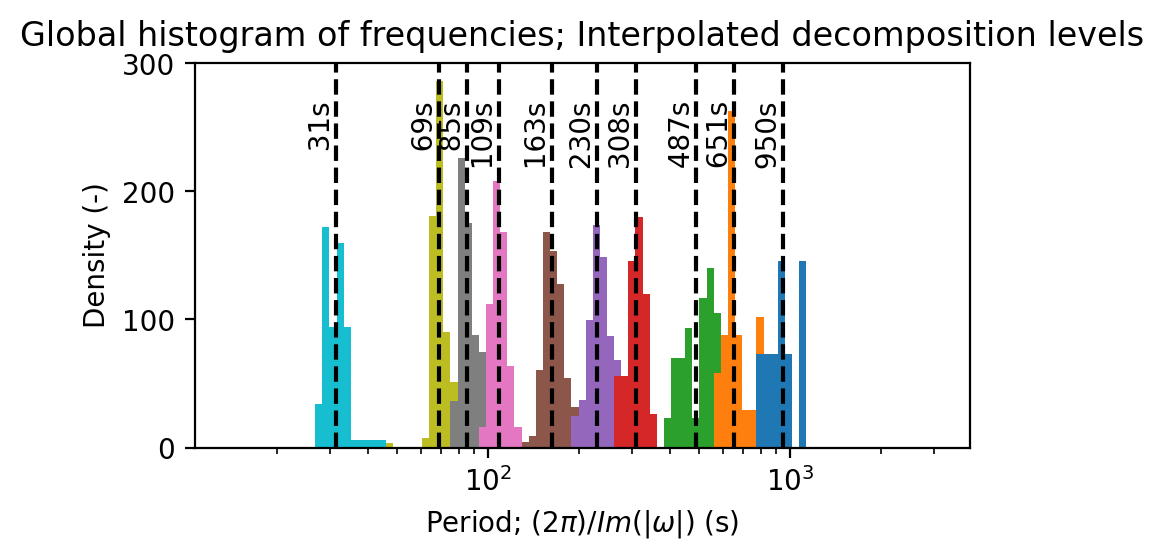

In [22]:
plt.figure(figsize=(5, 2.5))

plt.hist(
    x=x_trans_labels,
    bins=np.logspace(start=np.log10(14), stop=np.log10(3000), num=100),
    histtype="barstacked",
    weights=weights_labels,
)

ax = plt.gca()
ax.set_xscale("log")
ax.set_title(
    "Global histogram of frequencies; Interpolated decomposition levels"
)
ax.set_xlabel(r"Period; $(2 \pi) / Im(|\omega|)$ (s)")
ax.set_ylabel("Density (-)")
[
    ax.axvline(2 * np.pi / (10**c), color="k", ls="--")
    for nc, c in enumerate(cluster_centroids)
]

ylim_bottom, ylim_top = ax.get_ylim()
[
    ax.text(
        2 * np.pi / (10**c),
        ylim_top - ylim_top * 0.1,
        "{:4.0f}s".format(1 / (10 ** (c) / (2 * np.pi))),
        rotation="vertical",
        va="top",
        ha="right",
    )
    for c in cluster_centroids
];

We now have discrete frequency bands giving us the coherent spatialtemporal modes found by mrCOSTS. This is not meant to be a dimensionality reduction since we have gone from 80 spatial points into some number of coherent spatialtemporal modes. Instead, these are the physically meaningful processes with coherent spatial modes which would be otherwise extremely difficult to infer. 

Notes:

- We have now clearly captured the distinct frequency bands, regardless of which decomposition level they originally came from.
- Physically, we would expect the highest frequency bands to be made up of a melange of small scale processes that are only partially captured by the instrument. Instead, mrCOSTS suggests that coherent processes are not present at the finest time scales.
- This example highlights how the frequency band scale separation is not an "fire and forget" process but requires physical interprettation of results _a posteriori_.

# Evaluating the results

First, the mrCOSTS fit is used to reconstruct the discrete frequency bands. The resulting data is of the dimensions `n_decomp` x `n_frequency_bands` x `n_space` x `n_time`. In other worse, the 1D profile now has two more dimensions. 

The low-frequency background mode was excluded in the last decomposition level but it is necessary to include this component when reconstructing.

In [23]:
xr_sep = mrc.global_scale_reconstruction()
xr_background = mrc.get_background()

Now we plot the time-space cross sections for each coherent spatiotemporal mode.

As mentioned above, the high frequency component was split up across three clusters. Since processes at these fine time scales are anticipated to be poorly resolved by the instrument as well as being stochastic in nature, we simply exclude them here.

## Visualizing each band

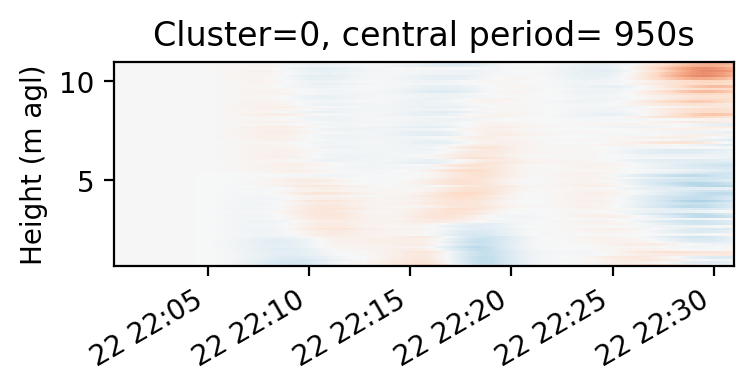

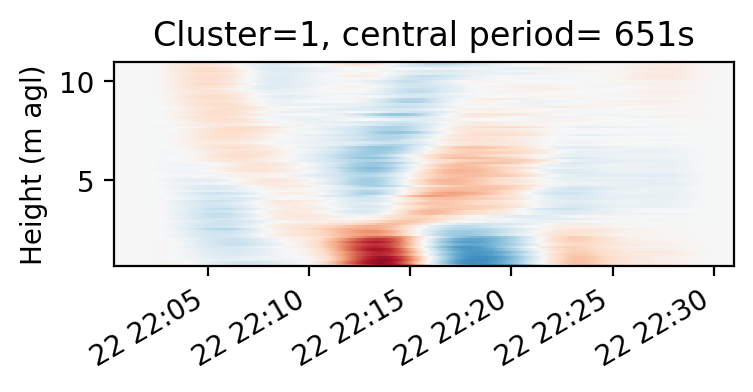

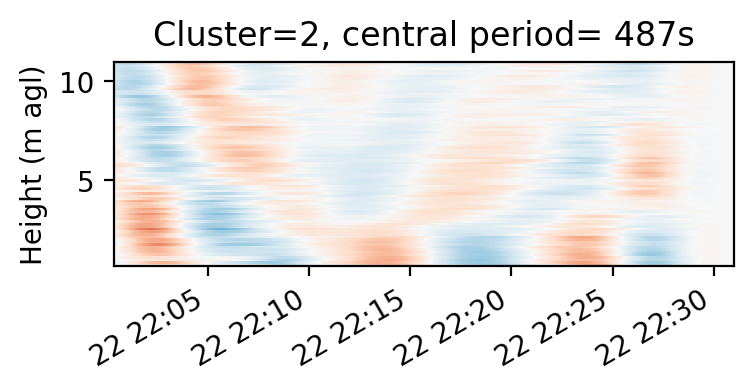

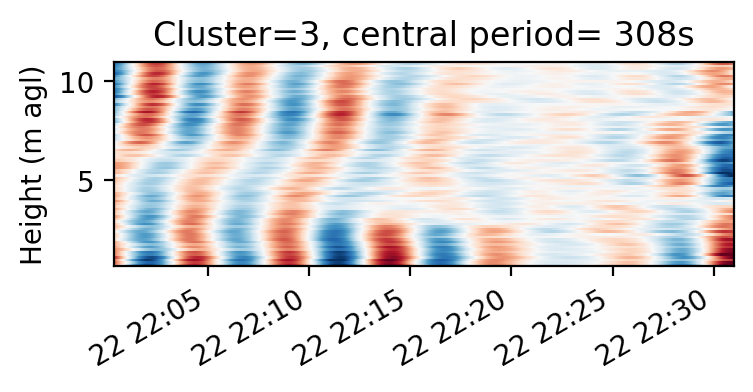

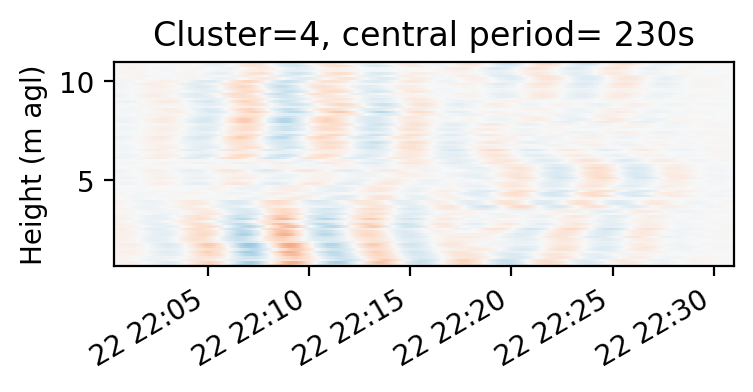

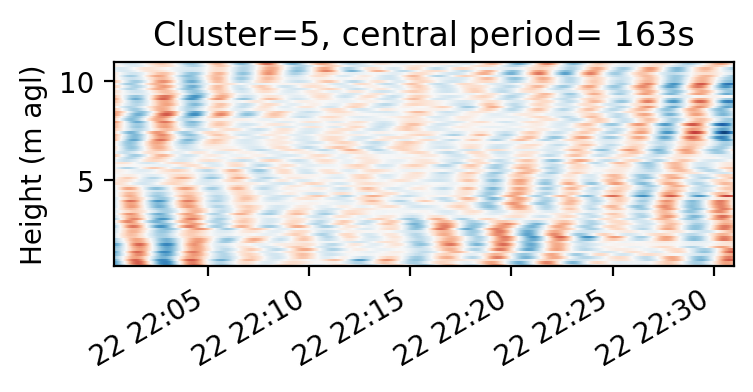

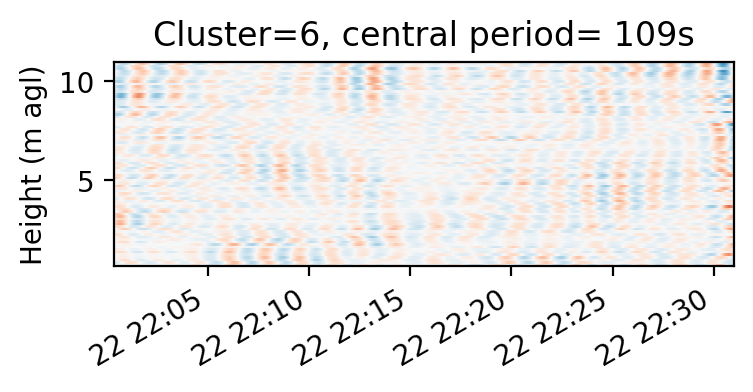

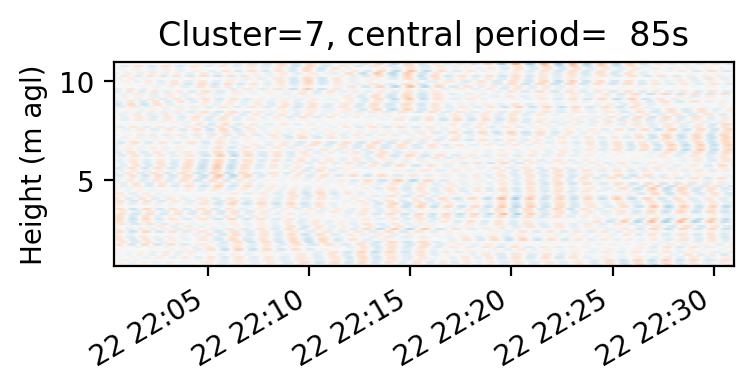

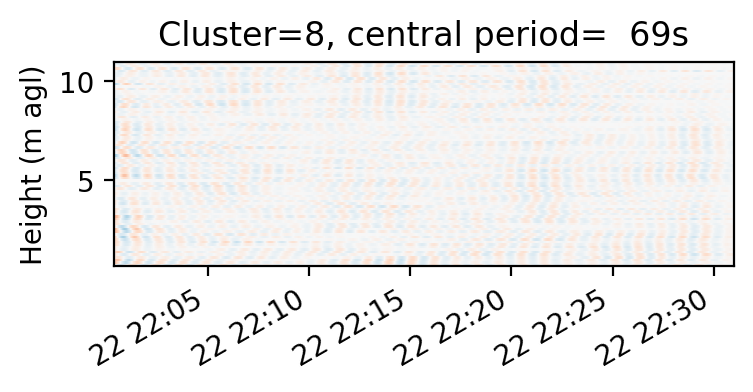

In [24]:
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi))

for ncl_center, cl_center in enumerate(cluster_centers_periods):
    if cl_center < 60:
        continue
    plt.figure(figsize=(4, 1.5))
    plt.pcolormesh(
        ds_data.time,
        ds_data.z,
        xr_sep[:, ncl_center, :, :].sum(axis=0),
        vmin=-0.5,
        vmax=0.5,
        cmap="RdBu_r",
    )
    plt.gca().set_title(
        "Cluster={}, central period={:4.0f}s".format(ncl_center, cl_center)
    )
    plt.gca().set_ylabel("Height (m agl)")
    plt.gcf().autofmt_xdate()

These discrete, coherent modes are a major breakthrough. No other method can separate them out.

Some of the modes are clearly very small amplitude, while others make up a dominant process scale.

What about the slow background mode?

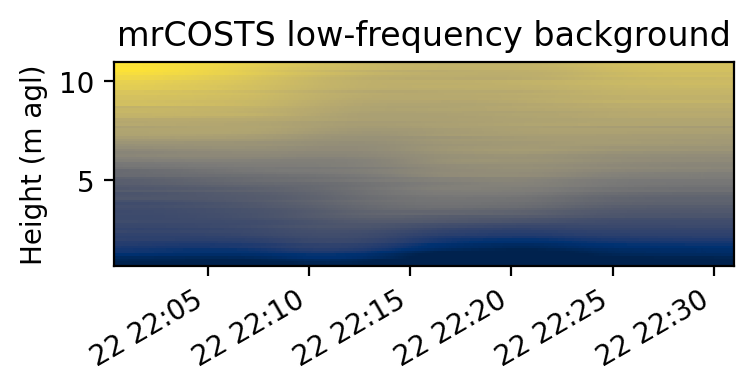

In [25]:
plt.figure(figsize=(4, 1.5))
plt.pcolormesh(
    ds_data.time, ds_data.z, xr_background, vmin=-2, vmax=2, cmap="cividis"
)
plt.gca().set_title("mrCOSTS low-frequency background")
plt.gca().set_ylabel("Height (m agl)")
plt.gcf().autofmt_xdate()

## Converting to xarray

You may have noted in the above code the somewhat complicated indexing, specifically selecting the correct frequency band in axis one and summing across decomposition levels in axis 0 in order to plot the time-space components held in the last two axes. This indexing problem only gets more complicated when considering non-1D data.

It is for precisely this problem that the xarray package was developed. Xarray allows us to name the dimensions and perform operations, such as indexing, using the named dimensions.

In [26]:
ds_xr_sep = xr.DataArray(
    xr_sep.real,
    dims=["decomp_level", "cluster", "z", "time"],
    coords=[
        np.arange(len(mrc.costs_array)),
        np.arange(n_optimal),
        ds_data.z,
        ds_data.time,
    ],
)
ds_cluster_centers = xr.DataArray(
    1 / (10 ** (cluster_centroids) / (2 * np.pi)),
    dims=["cluster"],
    coords=[np.arange(n_optimal)],
)
ds_cluster_centers.attrs["units"] = "s"
ds_cluster_centers.attrs["long_name"] = "Central period of each period band"

ds_global_separation = ds_xr_sep.to_dataset(name="frequency_bands")
ds_global_separation["frequency_bands"].attrs["units"] = "K"
ds_global_separation["frequency_bands"].attrs["long_name"] = "mrCOSTS"

ds_global_separation.coords["cluster_centers"] = ds_cluster_centers

ds_global_separation["background"] = (("z", "time"), xr_background)

ds_global_separation

<xarray.Dataset>
Dimensions:          (decomp_level: 3, cluster: 10, z: 80, time: 1838)
Coordinates:
  * decomp_level     (decomp_level) int64 0 1 2
  * cluster          (cluster) int64 0 1 2 3 4 5 6 7 8 9
  * z                (z) float64 0.7173 0.8461 0.9749 1.104 ... 10.64 10.77 10.9
  * time             (time) datetime64[ns] 2019-07-22T22:00:22 ... 2019-07-22...
    cluster_centers  (cluster) float64 950.2 650.9 487.4 ... 85.15 68.7 31.46
Data variables:
    frequency_bands  (decomp_level, cluster, z, time) float64 0.0 0.0 ... 0.0
    background       (z, time) float64 -2.097 -2.097 -2.097 ... 1.386 1.386

## Global reconstruction

In [27]:
xr_global_reconstruction = mrc.global_reconstruction()
da_global_reconstruction = xr.DataArray(
    data=xr_global_reconstruction,
    coords=[("z", ds_data.z.data), ("time", ds_data.time.data)],
)
da_global_reconstruction.attrs["units"] = "K"
da_global_reconstruction.attrs["long_name"] = r"$\theta - <\theta>$"

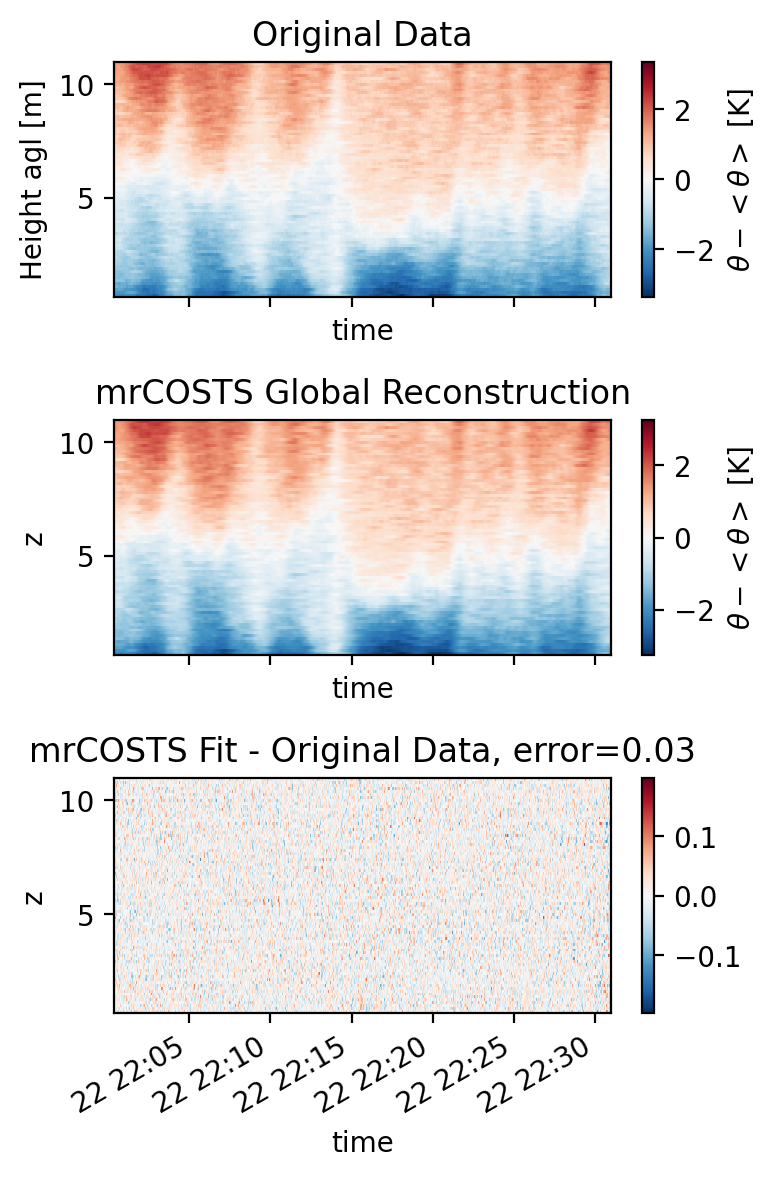

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(4, 6), sharex=True)

ax = axes[0]
ds_data.plot(ax=ax)
ax.set_title("Original Data")

ax = axes[1]
da_global_reconstruction.plot(ax=ax)
ax.set_title("mrCOSTS Global Reconstruction")

ax = axes[2]
(da_global_reconstruction - ds_data).plot(ax=ax)
error = mrd.relative_error(data, xr_global_reconstruction)
ax.set_title(f"mrCOSTS Fit - Original Data, error={error:.2f}")

fig.tight_layout()

The fit is very high fidelity, with no spatially correlated error.

## At a point

Plots of time series are generally easier for intuitive interpretation. For this reason we can generate plots of the observations, global reconstruction, and scale separation at a couple different locations.

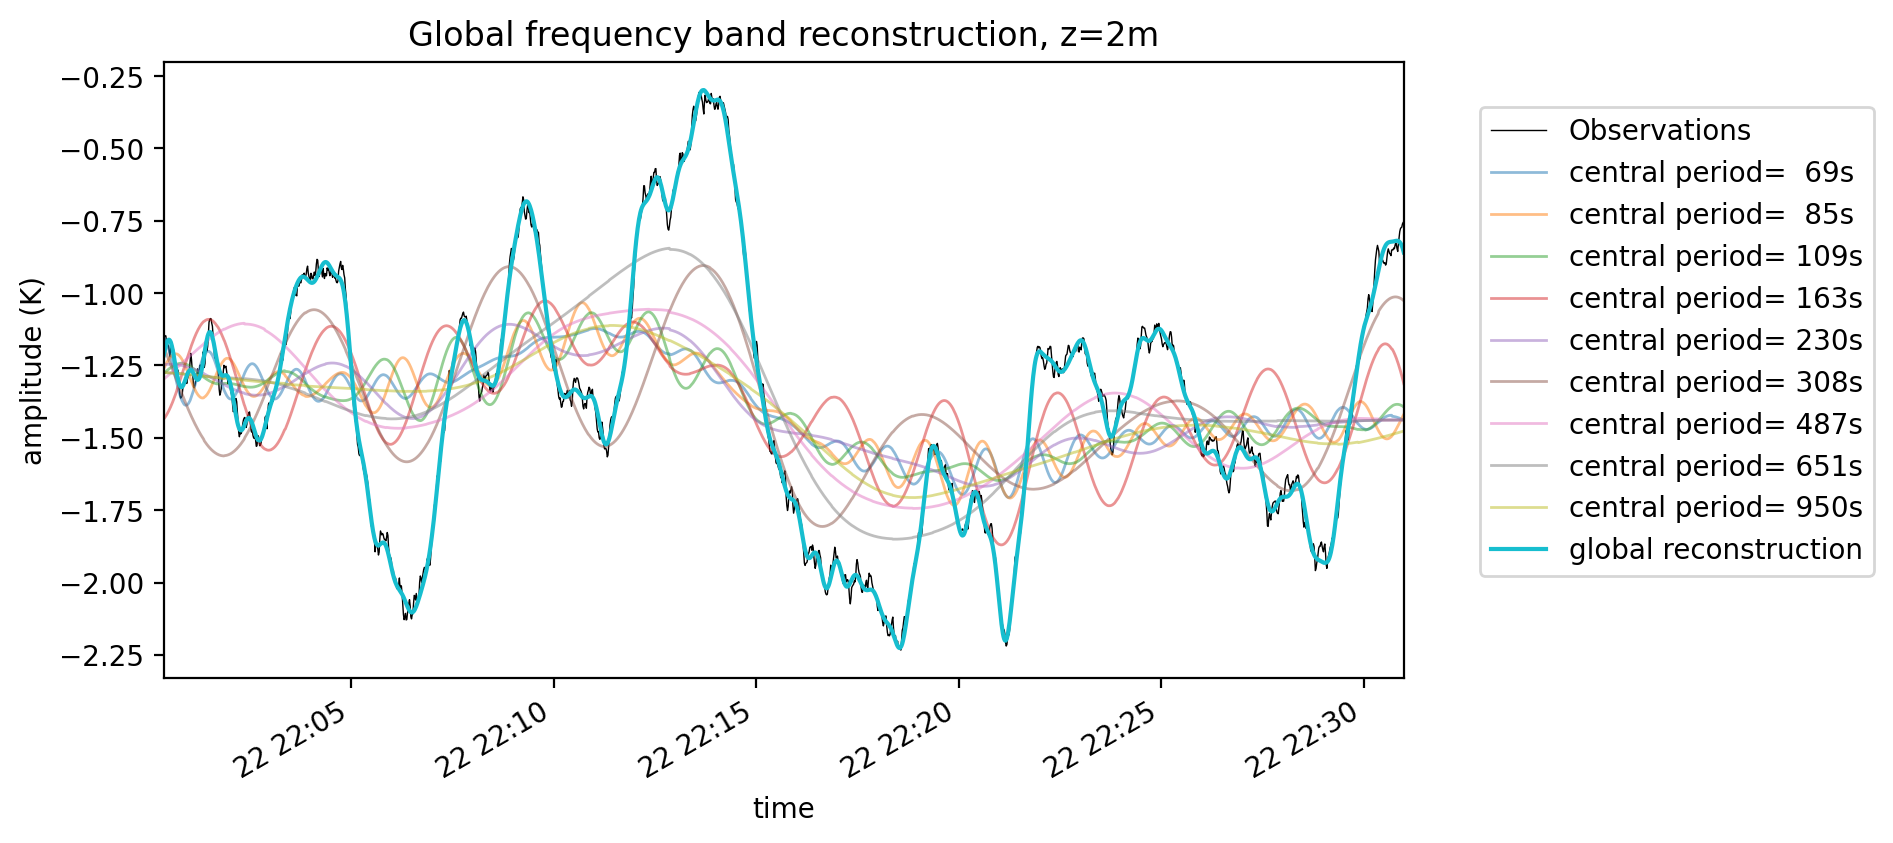

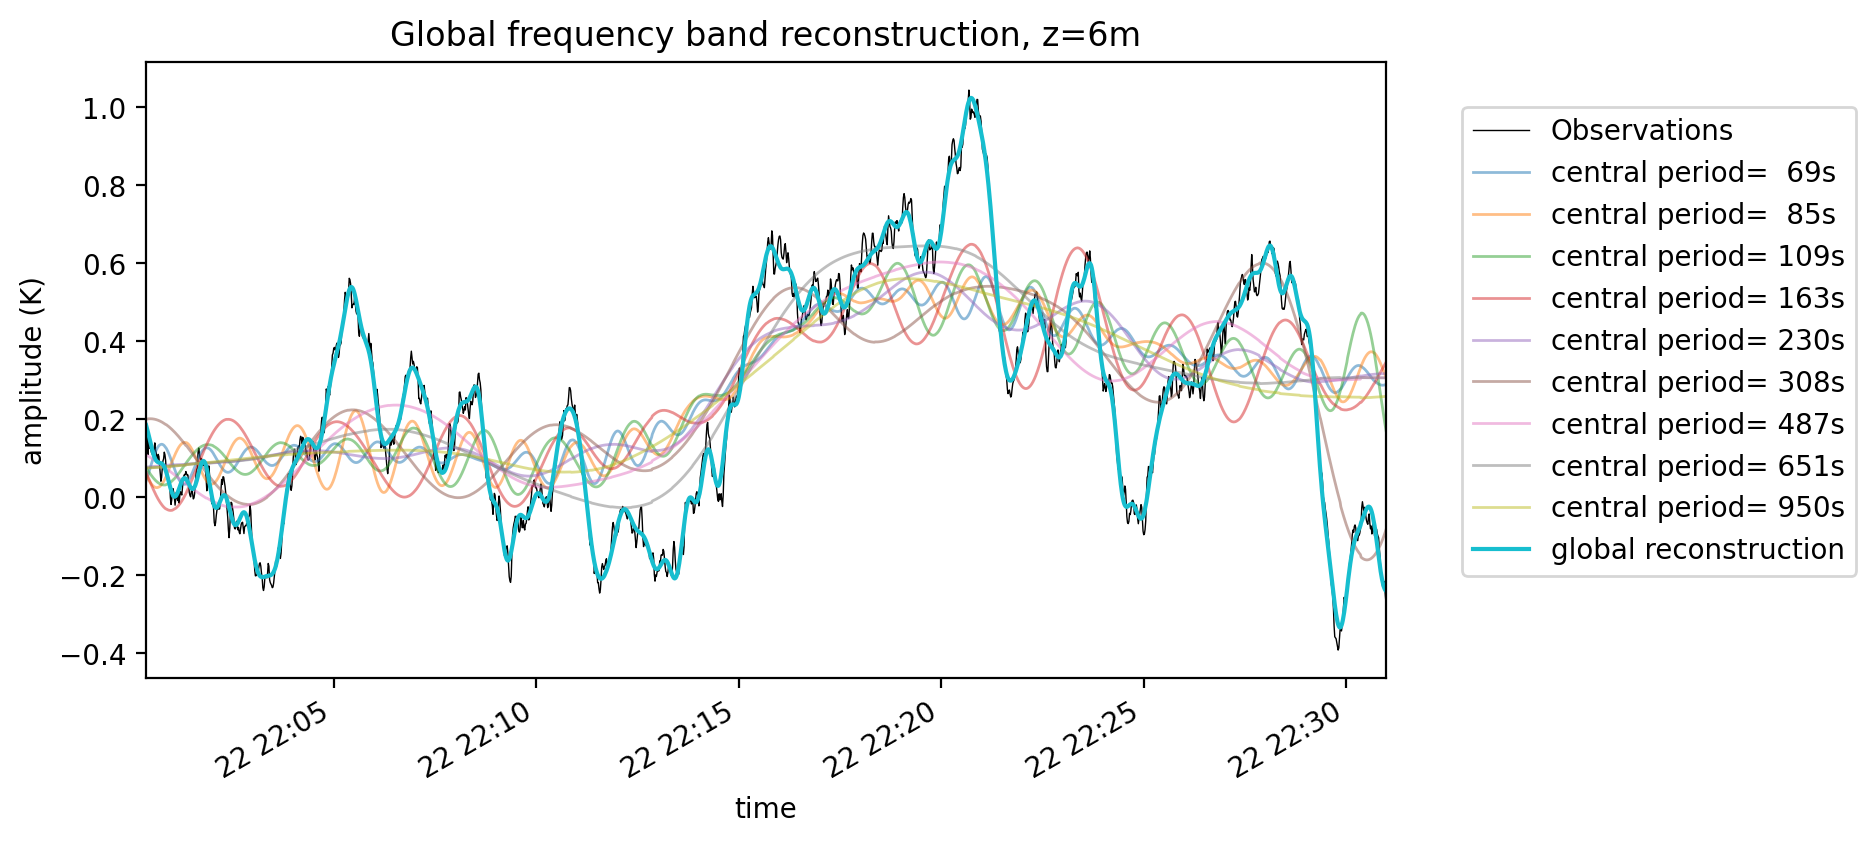

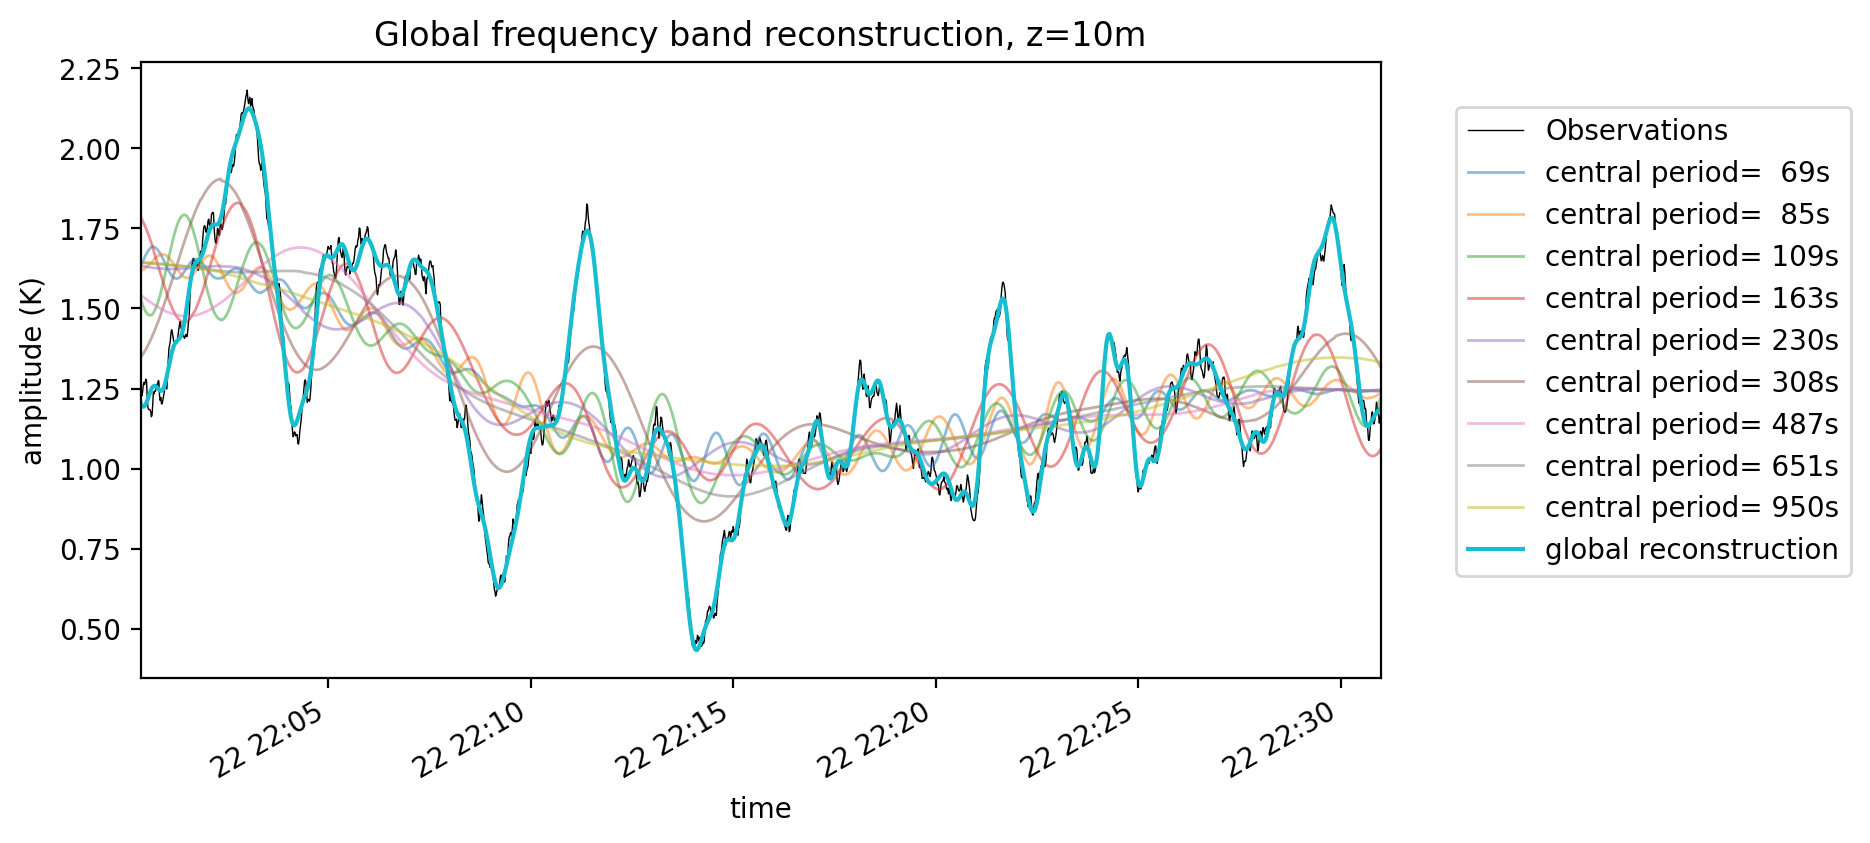

In [29]:
for z in [2, 6, 10]:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ground_truth = ds_data.sel(z=z, method="nearest")
    ground_truth = ground_truth
    ground_truth.plot(ax=ax, color="k", lw=0.5, label="Observations")

    background = ds_global_separation["background"].sel(z=z, method="nearest")

    for ncl, cl_center in enumerate(ds_global_separation.cluster_centers[::-1]):
        if cl_center < 60:
            continue
        ds_plot = (
            ds_global_separation["frequency_bands"]
            .swap_dims({"cluster": "cluster_centers"})
            .sel(cluster_centers=cl_center)
            .sel(z=z, method="nearest")
        ).sum(dim="decomp_level")
        label = "central period={:4.0f}s".format(cl_center.values)
        (ds_plot + background).plot(ax=ax, label=label, lw=1, alpha=0.5)

    da_global_reconstruction.sel(z=z, method="nearest").plot(
        label="global reconstruction"
    )

    # ax.legend()
    ax.legend(bbox_to_anchor=(1.05, 0.95))
    ax.set_title("Global frequency band reconstruction, z={}m".format(z))
    ax.set_ylabel("amplitude (K)")
    ax.autoscale(enable=True, axis="x", tight=True)

(Each frequency band is plotted with the background included to ease the visualization)